In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn import preprocessing
from sklearn.preprocessing import MultiLabelBinarizer
import seaborn as sns
from sklearn import metrics
from sklearn.feature_extraction import text 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import re 
from rapidfuzz import process, fuzz

In [2]:
df_admits = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\diagnoses_icd.csv.gz', compression='gzip')
df_transfers = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\emar.csv.gz', compression='gzip')

In [2]:
df_admits = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\diagnoses_icd.csv.gz', compression='gzip')
#df_transfers = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\emar.csv.gz', compression='gzip')

In [40]:
#print(df_admits.head(10))
#print(df_diagnosis.head(10))
#print(df_icd_proc.head(10))
#print(df_icd_diagnosis.head(10))
df_pat.head(10)

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13
5,10000102,F,27,2136,2008 - 2010,NaN
6,10000108,M,25,2163,2014 - 2016,NaN
7,10000115,M,24,2154,2017 - 2019,NaN
8,10000117,F,48,2174,2008 - 2010,NaN
9,10000161,M,60,2163,2020 - 2022,NaN


In [ ]:
# Data Checks

#df_admits.isna().any() # check which columns have NaN
df_admits.loc[:,df_admits.isna().any()]
#df_admits[df_admits['admission_location'] == '']
#pd.reset_option('display.max_rows')


In [ ]:
plt.barh(df_admits['admission_location'].value_counts().index,df_admits.admission_location.value_counts().values)
plt.show() # to check for missing values 

In [54]:
# Join diagnosis, admissions and procs
df_admit_icd = pd.merge(df_admits,df_diagnosis,how = 'left', on = 'hadm_id')
df_admit_diagnosis = pd.merge(df_admit_icd,df_icd_diagnosis,how = 'left', on = 'icd_code')
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_icd_proc,how = 'left', on = 'icd_code')
df_admit_diagnosis.drop(columns= ['subject_id_y'], inplace = True)
df_admit_diagnosis.rename(columns={'long_title_x': 'icd_diagnosis_name','long_title_y':'proc_name','subject_id_x':'subject_id'}, inplace=True)
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_pat[['subject_id', 'anchor_age','gender']],how = 'left', on = 'subject_id')

In [55]:
# Replace all NaN with 'No Diagnosis'
df_admit_diagnosis['icd_diagnosis_name'] = df_admit_diagnosis['icd_diagnosis_name'].fillna('No Diagnosis')
df_admit_diagnosis['proc_name'] = df_admit_diagnosis['proc_name'].fillna('No Procedure')
df_admit_diagnosis['icd_code'] = df_admit_diagnosis['icd_code'].fillna('No ICD Code')
df_admit_diagnosis[df_admit_diagnosis['proc_name'].isna()]

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,hospital_expire_flag,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender


In [56]:
df_admit_diagnosis.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,hospital_expire_flag,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,0,1.0,5723,9.0,9.0,Portal hypertension,NaN,No Procedure,52,F
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,0,2.0,78959,9.0,9.0,Other ascites,NaN,No Procedure,52,F
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,0,3.0,5715,9.0,9.0,Cirrhosis of liver without mention of alcohol,NaN,No Procedure,52,F
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,0,4.0,07070,9.0,9.0,Unspecified viral hepatitis C without hepatic ...,NaN,No Procedure,52,F
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,0,5.0,496,9.0,9.0,"Chronic airway obstruction, not elsewhere clas...",9.0,Excision of anus,52,F


Ensure normalisation of icd_diagnosis_name and proc_name

In [ ]:
my_stop_words = ['term','episode','eyes', 'face', 'facial','mouth','home','legs','pain'
                 ,'procedure','weight','adult','child','unspecified','primary','secondary','other','long'
                 ,'system', 'due', 'related', 'associated', 'organ', 'tissue', 'area', 'region', 'tract'
                 ,'side', 'lobe', 'part', 'left', 'right', 'bilateral', 'upper', 'lower', 'anterior'
                 ,'posterior', 'icd', 'code','type', 'specified', 'classification'
                 ,'history', 'present', 'past','recent', 'new', 'old','accessory','adhesive','body', 'blood'
                 ,'classified','unclassified']
combined_stop_words = list(text.ENGLISH_STOP_WORDS.union(my_stop_words))


def normalise_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)      # remove punctuation
    text = re.sub(r'\d+', '', text)          # remove numbers
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    tokens = text.split()                    # Tokenize
    filtered_tokens = [word for word in tokens if word not in combined_stop_words]  # Remove stop words
    return ' '.join(filtered_tokens)

In [ ]:
# Testing normalisation with subset
df_admit_diagnosis_subset = df_admit_diagnosis.loc[1:10000,:]
df_admit_diagnosis_subset['diagnosis_clean'] = df_admit_diagnosis_subset['icd_diagnosis_name'].apply(normalise_text)

C:\Users\smahmood\AppData\Local\Temp\ipykernel_8532\761817144.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_admit_diagnosis_subset['diagnosis_clean'] = df_admit_diagnosis_subset['icd_diagnosis_name'].apply(normalise_text)


In [93]:
unique_diagnoses = df_admit_diagnosis_subset['diagnosis_clean'].dropna().unique()

In [81]:
def standardise_similar_entries(unique_values, threshold=85):
    standardisation_map = {}
    value_list = list(unique_values)
    
    for i, current_value in enumerate(value_list):
        if current_value is None or current_value == '':
            continue  # skip empty
        
        if current_value in standardisation_map:
            continue  # already mapped
        
        # Create a list excluding current_value
        others = value_list[:i] + value_list[i+1:]
        
        match = process.extractOne(
            current_value,
            others,
            processor=None,
            scorer=fuzz.token_sort_ratio,
            score_cutoff=threshold
        )
        
        if match:
            matched_value = match[0]
            standardisation_map[matched_value] = current_value
            standardisation_map[current_value] = current_value
        else:
            # map self if no close match found
            standardisation_map[current_value] = current_value
            
    return standardisation_map

In [94]:
standardised_map_subset = standardise_similar_entries(unique_diagnoses)

In [95]:
df_admit_diagnosis_subset['diagnosis_name'] = df_admit_diagnosis_subset['diagnosis_clean'].map(standardised_map_subset).fillna(df_admit_diagnosis_subset['icd_diagnosis_name'])

C:\Users\smahmood\AppData\Local\Temp\ipykernel_8532\3282736867.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_admit_diagnosis_subset['diagnosis_name'] = df_admit_diagnosis_subset['diagnosis_clean'].map(standardised_map_subset).fillna(df_admit_diagnosis_subset['icd_diagnosis_name'])


In [97]:
df_admit_diagnosis_subset.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender,diagnosis_clean,diagnosis_name
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,78959,9.0,9.0,Other ascites,NaN,No Procedure,52,F,ascites,ascites
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,5715,9.0,9.0,Cirrhosis of liver without mention of alcohol,NaN,No Procedure,52,F,cirrhosis liver mention alcohol,cirrhosis liver mention alcohol
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,07070,9.0,9.0,Unspecified viral hepatitis C without hepatic ...,NaN,No Procedure,52,F,viral hepatitis c hepatic coma,viral hepatitis c hepatic coma
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,496,9.0,9.0,"Chronic airway obstruction, not elsewhere clas...",9.0,Excision of anus,52,F,chronic airway obstruction,chronic airway obstruction
5,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,29680,9.0,9.0,"Bipolar disorder, unspecified",NaN,No Procedure,52,F,bipolar disorder,bipolar disorder


In [103]:
## Actual 
df_admit_diagnosis['diagnosis_clean'] = df_admit_diagnosis['icd_diagnosis_name'].apply(normalise_text)
df_admit_diagnosis['procedure_clean'] = df_admit_diagnosis['proc_name'].apply(normalise_text)

unique_diagnoses = df_admit_diagnosis['diagnosis_clean'].dropna().unique()
unique_proc = df_admit_diagnosis['procedure_clean'].dropna().unique()

In [104]:
# Map the cleaned diagnosis to the standardised form
standardised_map_diagnosis = standardise_similar_entries(unique_diagnoses)
standardised_map_proc = standardise_similar_entries(unique_proc)

In [105]:
df_admit_diagnosis['diagnosis_name'] = df_admit_diagnosis['diagnosis_clean'].map(standardised_map_diagnosis).fillna(df_admit_diagnosis['icd_diagnosis_name'])
df_admit_diagnosis['procedure_name'] = df_admit_diagnosis['procedure_clean'].map(standardised_map_proc).fillna(df_admit_diagnosis['proc_name'])

In [106]:
df_admit_diagnosis.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender,diagnosis_clean,diagnosis_name,procedure_clean,procedure_name
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,9.0,Portal hypertension,NaN,No Procedure,52,F,portal hypertension,portal hypertension,,No Procedure
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,9.0,Other ascites,NaN,No Procedure,52,F,ascites,ascites,,No Procedure
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,9.0,Cirrhosis of liver without mention of alcohol,NaN,No Procedure,52,F,cirrhosis liver mention alcohol,cirrhosis liver mention alcohol,,No Procedure
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,9.0,Unspecified viral hepatitis C without hepatic ...,NaN,No Procedure,52,F,viral hepatitis c hepatic coma,viral hepatitis c hepatic coma,,No Procedure
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,9.0,"Chronic airway obstruction, not elsewhere clas...",9.0,Excision of anus,52,F,chronic airway obstruction,chronic airway obstruction,excision anus,excision anus


In [ ]:
diagnosis_counts = df_admit_diagnosis.diagnosis_name.value_counts()
proc_counts = df_admit_diagnosis.procedure_name.value_counts()

# Get the top 100 ICD codes by frequency
top_200_diagnosis = df_admit_diagnosis['diagnosis_name'].value_counts().nlargest(201).index
top_200_proc = df_admit_diagnosis['procedure_name'].value_counts().nlargest(201).index

# Map ICD codes — keep top 100, replace others with 'Other Code'
df_admit_diagnosis['diagnosis_converted'] = df_admit_diagnosis['diagnosis_name'].apply(
    lambda x: str(x) if x in top_200_diagnosis else 'Other Diagnosis'
)
df_admit_diagnosis['procedure_converted'] = df_admit_diagnosis['procedure_name'].apply(
    lambda x: str(x) if x in top_200_proc else 'Other Procedure'
)

df_admit_diagnosis.drop(columns = ['icd_version_y','icd_version_x','edregtime','edouttime','deathtime','admit_provider_id','hospital_expire_flag','icd_diagnosis_name','proc_name',
                                         'seq_num','icd_code','language','icd_version','diagnosis_clean','diagnosis_name','procedure_clean','procedure_name'],inplace = True)

In [114]:
df_admit_diagnosis.head()

,subject_id,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,marital_status,race,anchor_age,gender,diagnosis_converted,procedure_converted
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,52,F,portal hypertension,No Procedure
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,52,F,ascites,No Procedure
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,52,F,Other Diagnosis,No Procedure
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,52,F,viral hepatitis c hepatic coma,No Procedure
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,52,F,chronic airway obstruction,excision anus


In [116]:
pd.set_option('display.max_rows', 10)
print(df_admit_diagnosis.procedure_converted.value_counts().head(10000))

procedure_converted
No Procedure                                                  5918460
diagnostic procedures lymphatic structures                     102368
biopsy structure                                                67293
temporary tracheostomy                                          36349
repair urethra                                                  29143
                                                               ...   
osteoclasis patella                                               224
intrathoracic anastomosis esophagus                               223
dilation ureteral meatus                                          221
removal implanted lens                                            220
prophylactic vaccination arthropodborne viral encephalitis        220
Name: count, Length: 202, dtype: int64


In [117]:
# Group first to reduce data size
df_admit_diagnosis_grouped = df_admit_diagnosis.groupby(['hadm_id', 'subject_id']).agg({  
     'admission_type':'first',
     'admission_location': 'first',
     'discharge_location':'first',
     'admittime':'first',
     'dischtime':'first',
     'insurance':'first',
     'marital_status': 'first',
     'race':'first',
     'anchor_age': 'first',
     'gender':'first',
     'diagnosis_converted': lambda x: set(x),
     'procedure_converted': lambda x: set(x),
     }).reset_index()
df_admit_diagnosis_grouped.head(5)  

,hadm_id,subject_id,admission_type,admission_location,discharge_location,admittime,dischtime,insurance,marital_status,race,anchor_age,gender,diagnosis_converted,procedure_converted
0,20000019,10467237,EW EMER.,EMERGENCY ROOM,HOME,2159-03-20 21:08:00,2159-03-23 16:54:00,Medicaid,SINGLE,HISPANIC/LATINO - GUATEMALAN,76,F,"{hyperlipidemia, diabetes mellitus mention com...","{No Procedure, suture laceration palate, biops..."
1,20000024,16925328,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,2151-05-25 21:44:00,2151-05-26 18:36:00,Medicare,SINGLE,WHITE,84,F,"{essential hypertension, osteoporosis current ...",{No Procedure}
2,20000034,19430048,DIRECT OBSERVATION,PHYSICIAN REFERRAL,None,2174-05-22 19:13:00,2174-05-24 17:27:00,Medicare,SINGLE,BLACK/CARIBBEAN ISLAND,72,M,{diabetes mellitus diabetic chronic kidney dis...,"{No Procedure, physical rehabilitation diagnos..."
3,20000041,18910522,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,2143-09-03 07:15:00,2143-09-06 13:50:00,Private,SINGLE,WHITE,62,F,"{hyperlipidemia, bariatric surgery status, ess...","{biopsy structure, No Procedure, diagnostic pr..."
4,20000045,13413708,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,2138-05-21 16:25:00,2138-05-29 02:05:00,Private,DIVORCED,WHITE,51,F,"{disorders phosphorus metabolism, personal nic...",{No Procedure}


In [118]:
# Assign admission ranks throughout time
# Readmission is within 30 days of discharge and next admission so insert flag

df_admit_diagnosis_grouped['admittime'] = pd.to_datetime(df_admit_diagnosis_grouped['admittime'])
df_admit_diagnosis_grouped['dischtime'] = pd.to_datetime(df_admit_diagnosis_grouped['dischtime'])

df_admit_diagnosis_grouped['admission_rank'] = df_admit_diagnosis_grouped.groupby('subject_id')['admittime'].rank(method='dense', ascending=True)
df_admit_diagnosis_grouped.sort_values(by = ['admission_rank'],ascending= True, inplace= True)
# Get next admission's out time for each patient
df_admit_diagnosis_grouped['last_dischtime'] = df_admit_diagnosis_grouped.groupby('subject_id')['dischtime'].shift(1)

# Calculate days until next visit
df_admit_diagnosis_grouped['days_from_last'] = (df_admit_diagnosis_grouped['admittime'] - df_admit_diagnosis_grouped['last_dischtime']).dt.days

# Create readmission flag (1 if last visit is within 30 days, else 0)
df_admit_diagnosis_grouped['readmission'] = df_admit_diagnosis_grouped['days_from_last'].apply(lambda x: 1 if pd.notnull(x) and x <= 30 and x >= 0 else 0)

#df_admit_diagnosis_grouped[df_admit_diagnosis_grouped['subject_id'] == 10000032]

In [126]:
# label encode the text columns
df_admit_diagnosis_encoded = df_admit_diagnosis_grouped.drop(columns= ['admittime','dischtime','last_dischtime','days_from_last', 
                                                                       'admission_rank']) # drop irrelevant cols

cols_to_encode = ['admission_type','admission_location','discharge_location','insurance','race','gender','marital_status']
label_encoder = preprocessing.LabelEncoder()
for col in cols_to_encode:
    df_admit_diagnosis_encoded[col] = label_encoder.fit_transform(df_admit_diagnosis_encoded[col])
df_admit_diagnosis_encoded[df_admit_diagnosis_encoded['subject_id'] == 10000032]


,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,marital_status,race,anchor_age,gender,diagnosis_converted,procedure_converted,readmission
141961,22595853,10000032,8,8,6,0,3,28,52,0,"{viral hepatitis c hepatic coma, personal toba...","{No Procedure, excision anus}",0
155119,22841357,10000032,5,2,6,0,3,28,52,0,"{viral hepatitis c hepatic coma, tobacco use d...","{No Procedure, suture laceration palate, excis...",0
495453,29079034,10000032,5,2,6,0,3,28,52,0,"{chronic hepatitis c mention hepatic coma, tob...","{No Procedure, suture laceration palate, opera...",1
313493,25742920,10000032,5,2,8,0,3,28,52,0,"{chronic hepatitis c mention hepatic coma, tob...","{No Procedure, suture laceration palate, excis...",1


In [127]:
for col in ['diagnosis_converted', 'procedure_converted']:
    mlb = MultiLabelBinarizer(sparse_output=True)
    X = mlb.fit_transform(df_admit_diagnosis_encoded[col])
    df_encoded = pd.DataFrame.sparse.from_spmatrix(
        X,
        index=df_admit_diagnosis_encoded['hadm_id'],
        columns=[f"{c}" for c in mlb.classes_]
    )
    df_admit_diagnosis_encoded = df_admit_diagnosis_encoded.merge(
        df_encoded, left_on='hadm_id', right_index=True, how='left'
    )

In [128]:
pd.set_option('display.max_columns', None)
df_admit_diagnosis_encoded.head()

,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,marital_status,race,anchor_age,gender,diagnosis_converted,procedure_converted,readmission,Other Diagnosis,abnormal coagulation profile,accident,accidents occurring place,accidents occurring residential institution,acidosis,acquired hypothyroidism,acute chronic diastolic congestive heart failure,acute chronic diastolic heart failure,acute chronic systolic congestive heart failure,acute chronic systolic heart failure,acute kidney failure,acute kidney failure tubular necrosis,acute posthemorrhagic anemia,acute respiratory failure,adverse effect antineoplastic immunosuppressive drugs initial encounter,alcohol abuse,alcoholic cirrhosis liver,anemia chronic kidney disease,anxiety disorder,anxiety state,aortic valve disorders,aortocoronary bypass status,ascites,asthma,asthma uncomplicated,atherosclerotic heart disease native coronary artery unstable angina pectoris,atrial fibrillation,atrial flutter,bacteremia,bandemia,bariatric surgery status,benign prostatic hyperplasia urinary symptoms,bipolar ii disorder,cardiac dysrhythmias,cardiac pacemaker situ,cardiomyopathies,cellulitis abscess foot toes,chest,chronic,chronic airway obstruction,chronic hepatitis c mention hepatic coma,chronic kidney disease,chronic kidney disease stage iii moderate,chronic kidney disease stage severe,chronic obstructive pulmonary disease,chronic pulmonary heart diseases,cirrhosis liver,congestive heart failure,constipation,contact suspected exposure covid,contact suspected exposure viral communicable diseases,coronary atherosclerosis native coronary artery,coronary atherosclerosis vessel native graft,current use anticoagulants,current use antithromboticsantiplatelets,current use insulin,dehydration,dependence machines supplemental oxygen,dependence renal dialysis,depressive disorder,diabetes mellitus diabetic autonomic polyneuropathy,diabetes mellitus diabetic chronic kidney disease,diabetes mellitus diabetic mononeuropathy,diabetes mellitus diabetic peripheral angiopathy gangrene,diabetes mellitus hyperglycemia,diabetes mellitus mention complication ii stated uncontrolled,diabetes mellitus skin complications,diabetes neurological manifestations ii stated uncontrolled,diabetes renal manifestations ii stated uncontrolled,diarrhea,dining room noninstitutional private residence place occurrence external cause,disorders phosphorus metabolism,diverticulosis colon mention hemorrhage,dizziness giddiness,dysphagia,elevated white cell count,encephalopathy,encounter antineoplastic chemotherapy,encounter immunization,encounter palliative care,end stage renal disease,epilepsy intractable status epilepticus,epilepsy mention intractable epilepsy,esophageal reflux,essential hypertension,fall,fall stairs ladders water transport injuring person,falling,family ischemic heart disease diseases circulatory,fever,fluid overload,gastroesophageal reflux disease esophagitis,gastroparesis,glaucoma,gout,headache,hepatic encephalopathy,hypercalcemia,hyperlipidemia,hyperpotassemia,hypertensive chronic kidney disease malignant chronic kidney disease stage stage iv,hypertensive chronic kidney disease malignant chronic kidney disease stage v end stage renal disease,hypertensive chronic kidney disease stage stage chronic kidney disease chronic kidney disease,hypertrophy benign prostate urinary obstruction urinary symptom luts,hypocalcemia,hypokalemia,hypoosmolality hyponatremia,hyposmolality andor hyponatremia,hypotension,hypothyroidism,hypovolemia,hypoxemia,insomnia,knee joint replacement,leukocytosis,longterm current use aspirin,longterm current use insulin,major depressive disorder single,malignant hypertensive heart disease heart failure,malignant neoplasm lung,malignant neoplasm main bronchus,mass index,mass index bmi,menstrual migraine intractable status migrainosus,menstrual migraine mention intractable migraine mention status migrainosus,mitral valve disorders,morbid obesity,morbid severe obesity exce

In [143]:
df_admit_diagnosis_encoded.drop(columns=['diagnosis_converted','procedure_converted'], inplace= True)

In [144]:
print("Length of Original Data: ",len(df_admit_diagnosis_encoded))
print("Length of Data After MLB: ",len(df_admit_diagnosis_encoded))

Length of Original Data:  546028
Length of Data After MLB:  546028


Encode Medication Data

In [130]:
df_medi.drop(columns = ['enter_provider_id','charttime','scheduletime','storetime','emar_id','emar_seq','poe_id','pharmacy_id','enter_provider_id'
                        ,'charttime','scheduletime','storetime'], inplace= True)
df_medi['medication'] = df_medi['medication'].fillna('No Medication')
df_medi.head(5)

,subject_id,hadm_id,medication,event_txt
0,10000032,22595853.0,Heparin,Administered
1,10000032,22595853.0,Raltegravir,Administered
2,10000032,22595853.0,Sodium Chloride 0.9% Flush,Flushed
3,10000032,22595853.0,Nicotine Patch,Not Applied
4,10000032,22595853.0,Furosemide,Not Given


In [131]:
# Define grouping rules for usage
administered = [
    'Administered', 'Partial Administered', 'Applied',
    'Confirmed', 'Started', 'Administered in Other Location',
    'Started in Other Location', 'Administered Bolus from IV Drip',
    'Applied in Other Location', 'Removed Existing / Applied New',
    'Removed Existing / Applied New in Other Location',
    'Restarted', 'Restarted in Other Location'
]

not_administered = [
    'Not Applied', 'Not Given', 'Not Flushed', 'Hold Dose', 'Removed',
    'Not Confirmed', 'Not Started', 'Not Assessed', 'Not Removed',
    'Not Stopped', 'Not Read', 'Not Given per Sliding Scale',
    'Not Stopped per Sliding Scale', 'Not Started per Sliding Scale',
    'Not Given per Sliding Scale in Other Location', 'Read', 'Read in Other Location', 'Stopped', 'Stopped As Directed',
    'Stopped - Unscheduled', 'Stopped - Unscheduled in Other Location',
    'Rate Change', 'Rate Change in Other Location','Removed in Other Location',
    'Confirmed in Other Location'

]

delayed = [s for s in df_medi['event_txt'].dropna().unique() if s.startswith('Delayed')]

other = [
    'Flushed', 'Flushed in Other Location', 'Assessed',
    'Assessed in Other Location', 'Infusion Reconciliation',
    'Infusion Reconciliation Not Done', 'Pain score re-assessment',
    'Pain score re-assess not done', 'Documented in O.R. Holding',
    'TPN Rate Not Changed', ' in Other Location', 'Partial ',
]

In [132]:
# Make sure event lists are sets for faster lookup
administered_set = set(administered)
not_administered_set = set(not_administered)
delayed_set = set(delayed)

# Initialize with 'Other'
df_medi['usage'] = 'Other'

# Apply conditions using boolean indexing
mask_admin = df_medi['event_txt'].isin(administered_set) & (df_medi['medication'] != 'No Medication')
mask_not_admin = df_medi['event_txt'].isin(not_administered_set)
mask_delayed = df_medi['event_txt'].isin(delayed_set)

df_medi.loc[mask_admin, 'usage'] = 'Administered'
df_medi.loc[mask_not_admin, 'usage'] = 'Not Administered'
df_medi.loc[mask_delayed, 'usage'] = 'Delayed'

# Filter to only include 'Administered'
df_medi = df_medi[df_medi['usage'] == 'Administered']
df_medi['medication'] = df_medi['medication'].str.lower()

In [133]:
df_medi[df_medi['usage']=='Administered']

,subject_id,hadm_id,medication,event_txt,usage
0,10000032,22595853.0,heparin,Administered,Administered
1,10000032,22595853.0,raltegravir,Administered,Administered
7,10000032,22595853.0,albuterol inhaler,Administered,Administered
8,10000032,22595853.0,furosemide,Administered,Administered
9,10000032,22595853.0,spironolactone,Administered,Administered
...,...,...,...,...,...
42808584,19999828,29734428.0,lorazepam,Administered,Administered
42808585,19999828,29734428.0,insulin,Administered,Administered
42808588,19999828,NaN,morphine sulfate,Administered,Administered
42808590,19999828,NaN,ondansetron,Administered,Administered


In [134]:
top_100_meds = df_medi['medication'].value_counts().nlargest(201).index

df_medi['medication_grouped'] = df_medi['medication'].apply(
    lambda x: str(x) if x in top_100_meds else 'Other Medication'
)

In [135]:
# Group first to reduce data size
df_medi.drop(columns=['medication','event_txt','usage'],inplace=True)

df_medi_grouped = df_medi.groupby(['hadm_id', 'subject_id']).agg({  
     'medication_grouped': lambda x: set(x),
     }).reset_index()
df_medi_grouped.head(5)  

,hadm_id,subject_id,medication_grouped
0,20000024.0,16925328,"{heparin, acetaminophen, thiamine, oxycodone (..."
1,20000034.0,19430048,"{heparin, docusate sodium, cyanocobalamin, mul..."
2,20000045.0,13413708,"{hydromorphone (dilaudid), acetaminophen, dexa..."
3,20000147.0,14990224,"{hydromorphone (dilaudid), metoclopramide, sim..."
4,20000180.0,15296741,"{hydromorphone (dilaudid), ceftriaxone, bisaco..."


In [136]:
mlb = MultiLabelBinarizer(sparse_output=True)
X = mlb.fit_transform(df_medi_grouped['medication_grouped'])

df_medi_encoded = pd.DataFrame.sparse.from_spmatrix(
    X,
    index=df_medi_grouped['hadm_id'],
    columns=mlb.classes_
)

In [137]:
df_medi_encoded.drop(columns=['Other Medication'], inplace=True)

In [145]:
df_full_dataset = pd.merge(
    df_admit_diagnosis_encoded,
    df_medi_encoded,
    how='left',
    on='hadm_id'
)
df_full_dataset.fillna(0, inplace=True)

In [146]:
df_full_dataset

,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,marital_status,race,anchor_age,gender,readmission,Other Diagnosis,abnormal coagulation profile,accident,accidents occurring place,accidents occurring residential institution,acidosis,acquired hypothyroidism,acute chronic diastolic congestive heart failure,acute chronic diastolic heart failure,acute chronic systolic congestive heart failure,acute chronic systolic heart failure,acute kidney failure,acute kidney failure tubular necrosis,acute posthemorrhagic anemia,acute respiratory failure,adverse effect antineoplastic immunosuppressive drugs initial encounter,alcohol abuse,alcoholic cirrhosis liver,anemia chronic kidney disease,anxiety disorder,anxiety state,aortic valve disorders,aortocoronary bypass status,ascites,asthma,asthma uncomplicated,atherosclerotic heart disease native coronary artery unstable angina pectoris,atrial fibrillation,atrial flutter,bacteremia,bandemia,bariatric surgery status,benign prostatic hyperplasia urinary symptoms,bipolar ii disorder,cardiac dysrhythmias,cardiac pacemaker situ,cardiomyopathies,cellulitis abscess foot toes,chest,chronic,chronic airway obstruction,chronic hepatitis c mention hepatic coma,chronic kidney disease,chronic kidney disease stage iii moderate,chronic kidney disease stage severe,chronic obstructive pulmonary disease,chronic pulmonary heart diseases,cirrhosis liver,congestive heart failure,constipation,contact suspected exposure covid,contact suspected exposure viral communicable diseases,coronary atherosclerosis native coronary artery,coronary atherosclerosis vessel native graft,current use anticoagulants,current use antithromboticsantiplatelets,current use insulin,dehydration,dependence machines supplemental oxygen,dependence renal dialysis,depressive disorder,diabetes mellitus diabetic autonomic polyneuropathy,diabetes mellitus diabetic chronic kidney disease,diabetes mellitus diabetic mononeuropathy,diabetes mellitus diabetic peripheral angiopathy gangrene,diabetes mellitus hyperglycemia,diabetes mellitus mention complication ii stated uncontrolled,diabetes mellitus skin complications,diabetes neurological manifestations ii stated uncontrolled,diabetes renal manifestations ii stated uncontrolled,diarrhea,dining room noninstitutional private residence place occurrence external cause,disorders phosphorus metabolism,diverticulosis colon mention hemorrhage,dizziness giddiness,dysphagia,elevated white cell count,encephalopathy,encounter antineoplastic chemotherapy,encounter immunization,encounter palliative care,end stage renal disease,epilepsy intractable status epilepticus,epilepsy mention intractable epilepsy,esophageal reflux,essential hypertension,fall,fall stairs ladders water transport injuring person,falling,family ischemic heart disease diseases circulatory,fever,fluid overload,gastroesophageal reflux disease esophagitis,gastroparesis,glaucoma,gout,headache,hepatic encephalopathy,hypercalcemia,hyperlipidemia,hyperpotassemia,hypertensive chronic kidney disease malignant chronic kidney disease stage stage iv,hypertensive chronic kidney disease malignant chronic kidney disease stage v end stage renal disease,hypertensive chronic kidney disease stage stage chronic kidney disease chronic kidney disease,hypertrophy benign prostate urinary obstruction urinary symptom luts,hypocalcemia,hypokalemia,hypoosmolality hyponatremia,hyposmolality andor hyponatremia,hypotension,hypothyroidism,hypovolemia,hypoxemia,insomnia,knee joint replacement,leukocytosis,longterm current use aspirin,longterm current use insulin,major depressive disorder single,malignant hypertensive heart disease heart failure,malignant neoplasm lung,malignant neoplasm main bronchus,mass index,mass index bmi,menstrual migraine intractable status migrainosus,menstrual migraine mention intractable migraine mention status migrainosus,mitral valve disorders,morbid obesity,morbid severe obesity excess calories,motorcycle driver injured co

In [147]:
X = df_full_dataset.drop('readmission', axis=1)
y = df_full_dataset.readmission

In [148]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [149]:
logreg = LogisticRegression(penalty= 'l1',solver='liblinear',  random_state=42, max_iter=1000)

# fit the model with data
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

c:\Users\smahmood\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\smahmood\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [150]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[106670,   2106],
       [ 24733,   2998]])

Text(0.5, 427.9555555555555, 'Predicted label')

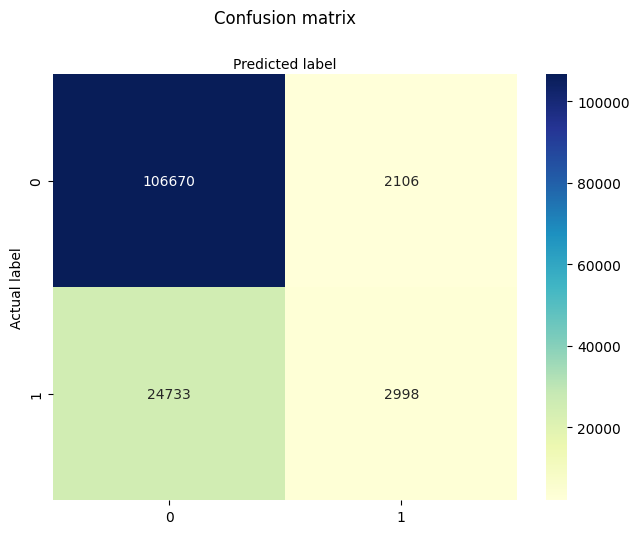

In [151]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')


In [152]:
target_names = ['not readmission', 'readmission']
print(classification_report(y_test, y_pred, target_names=target_names))

                 precision    recall  f1-score   support

not readmission       0.81      0.98      0.89    108776
    readmission       0.59      0.11      0.18     27731

       accuracy                           0.80    136507
      macro avg       0.70      0.54      0.54    136507
   weighted avg       0.77      0.80      0.74    136507



c:\Users\smahmood\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


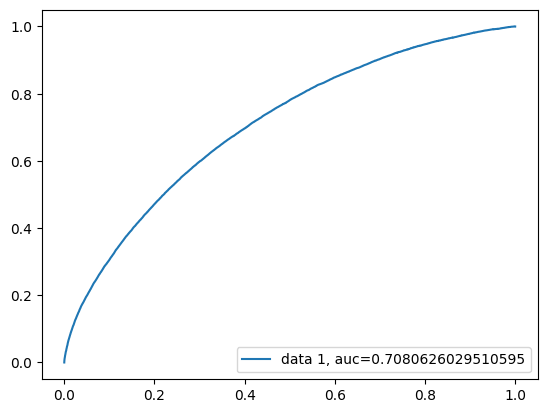

In [153]:
y_pred_proba = logreg.predict_proba(X_test)[::,1] # gets confidence level for each prediction
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

In [154]:
coef = logreg.coef_[0]  # For binary classification
feature_names = X_train.columns  

In [155]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef,
    'Abs_Coefficient': np.abs(coef),
    'Diagnosis Name': "",
    'Procedure Name': "",
    "Medication Name": ""
})

In [157]:
# Prepare lookup tables
diagnosis_lookup = df_admit_diagnosis['diagnosis_converted'].unique()
proc_lookup = df_admit_diagnosis['procedure_converted'].unique()
diagnosis_lookup = diagnosis_lookup[diagnosis_lookup != 'Other Diagnosis']
proc_lookup = proc_lookup[proc_lookup != 'Other Procedure']
medication_lookup = df_medi['medication_grouped'].unique()  


# Loop through each row
for idx, row in coef_df.iterrows():
    feature = row['Feature']

    if feature in diagnosis_lookup:
        coef_df.at[idx, 'Diagnosis Name'] = feature
    
    if feature in proc_lookup:
        coef_df.at[idx, 'Procedure Name'] = feature

    # If it's a medication, keep the name
    if feature in medication_lookup:
        coef_df.at[idx, 'Medication Name'] = feature



In [158]:
# Sort by absolute impact
coef_df_abs = coef_df.sort_values(by='Abs_Coefficient', ascending=False)
coef_df_abs.head(10)

,Feature,Coefficient,Abs_Coefficient,Diagnosis Name,Procedure Name,Medication Name
88,encounter antineoplastic chemotherapy,1.935185,1.935185,encounter antineoplastic chemotherapy,,
139,motorcycle driver injured collision fixed stat...,-1.516792,1.516792,motorcycle driver injured collision fixed stat...,,
325,local excision destruction lesion joint shoulder,-1.242528,1.242528,,local excision destruction lesion joint shoulder,
196,single live birth,-1.199670,1.199670,single live birth,,
254,closure nasal fistula,-1.125170,1.125170,,closure nasal fistula,
557,nimodipine,-1.100525,1.100525,,,nimodipine
293,gastrotomy,-1.098126,1.098126,,gastrotomy,
398,synovectomy elbow,-0.985950,0.985950,,synovectomy elbow,
237,biopsy scrotum tunica vaginalis,-0.968626,0.968626,,biopsy scrotum tunica vaginalis,
226,arthroscopy site,-0.907164,0.907164,,arthroscopy site,


In [159]:
coef_df_pstve = coef_df.sort_values(by='Coefficient', ascending=False)
coef_df_pstve.head(10)

,Feature,Coefficient,Abs_Coefficient,Diagnosis Name,Procedure Name,Medication Name
88,encounter antineoplastic chemotherapy,1.935185,1.935185,encounter antineoplastic chemotherapy,,
363,reconstructive refractive surgery cornea,0.822454,0.822454,,reconstructive refractive surgery cornea,
197,suicidal ideation,0.745934,0.745934,suicidal ideation,,
200,surgical procedures cause abnormal reaction pa...,0.723240,0.723240,surgical procedures cause abnormal reaction pa...,,
312,keratoprosthesis,0.715413,0.715413,,keratoprosthesis,
232,biopsy cornea,0.635084,0.635084,,biopsy cornea,
199,surgical operations procedures causing abnorma...,0.611046,0.611046,surgical operations procedures causing abnorma...,,
609,vancomycin oral liquid,0.603912,0.603912,,,vancomycin oral liquid
348,osteoclasis patella,0.603694,0.603694,,osteoclasis patella,
298,incision excision congenital septum uterus,0.591584,0.591584,,incision excision congenital septum uterus,


In [160]:
coef_df_ngtve = coef_df.sort_values(by='Coefficient', ascending=True)
coef_df_ngtve.head(10)

,Feature,Coefficient,Abs_Coefficient,Diagnosis Name,Procedure Name,Medication Name
139,motorcycle driver injured collision fixed stat...,-1.516792,1.516792,motorcycle driver injured collision fixed stat...,,
325,local excision destruction lesion joint shoulder,-1.242528,1.242528,,local excision destruction lesion joint shoulder,
196,single live birth,-1.199670,1.199670,single live birth,,
254,closure nasal fistula,-1.125170,1.125170,,closure nasal fistula,
557,nimodipine,-1.100525,1.100525,,,nimodipine
293,gastrotomy,-1.098126,1.098126,,gastrotomy,
398,synovectomy elbow,-0.985950,0.985950,,synovectomy elbow,
237,biopsy scrotum tunica vaginalis,-0.968626,0.968626,,biopsy scrotum tunica vaginalis,
226,arthroscopy site,-0.907164,0.907164,,arthroscopy site,
392,suture flexor tendon hand,-0.874212,0.874212,,suture flexor tendon hand,
